In [1]:
import oommfc as oc
import micromagneticdata as md
import discretisedfield as df
import functools
import matplotlib.pyplot as plt
import micromagneticmodel as mm
import os 
import re

In [2]:
def get_mesh(D: float, w: float):
    r = D / 2
    p10 = (-r, -r, 0)
    p20 = (r, r, 16.8e-9)

    region = df.Region(p1=p10, p2=p20)
    subregions = {
        "bottom": df.Region(p1=p10, p2=(r, r, 8e-9)),
        "spacer": df.Region(p1=(-r, -r, 8e-9), p2=(r, r, (8 + w) * 1e-9)),
        "top": df.Region(p1=(-r, -r, (8 + w) * 1e-9), p2=p20),
    }

    mesh = df.Mesh(region=region, cell=(3e-9, 3e-9, 8e-10), subregions=subregions)

    return mesh


def Ms_init(pos, Ms, D):
    x, y, z = pos
    r = D / 2
    if (x**2 + y**2) ** 0.5 < r:
        if z < 8e-9:
            return -Ms
        else:
            return Ms
    else:
        return 0


def m_init(pos, d):
    x, y, z = pos
    r = d / 2
    if (x**2 + y**2) ** 0.5 < r:
        return (0, 0, -1)
    else:
        return (0, 0, 1)

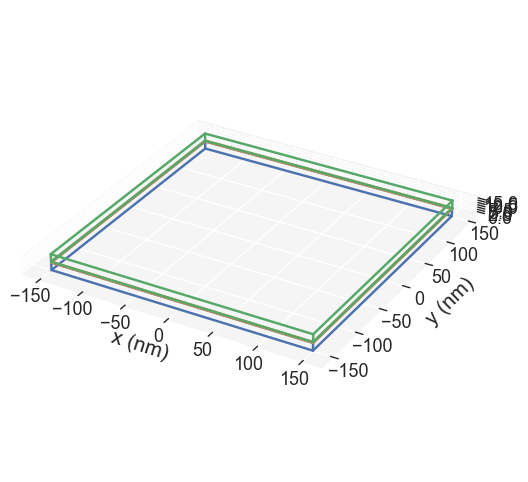

In [3]:
D = 300e-9
w = 0.8
Ms = 280e3
mesh = get_mesh(D, w)
mesh.mpl.subregions()

In [7]:
RESULTS_PATH_HYSTERESIS = "../results/saf_skyrmion-0.8nm-d_1-hysteresis"
d = 40e-9
Ms_fun = functools.partial(Ms_init, Ms=Ms, D=D)
m_fun = functools.partial(m_init, d=d)


A = 1e-11  # J/m
sigma = -0.3e-3  # J/m^2
K = 0.1e6  # J/m^3
dmi = 1e-3  # J/m^2
system = mm.System(name="saf_skyrmion_hysteresis")
system.energy = (
    mm.Exchange(A=A)
    + mm.RKKY(sigma=sigma, sigma2=0, subregions=["bottom", "top"])
    + mm.UniaxialAnisotropy(K=K, u=(0, 0, 1))
    + mm.Demag()
    + mm.DMI(D=dmi, crystalclass="Cnv_z")
)
norm = {"bottom": Ms_fun, "top": Ms_fun, "spacer": 0}
system.m = df.Field(mesh, nvdim=3, value=m_fun, norm=norm, valid="norm")

md = oc.MinDriver()
md.drive(
    system,
    dirname=f"{RESULTS_PATH_HYSTERESIS}/saf_skyrmion-{D / 1e-9:.0f}nm-{Ms / 1e3:.0f}kA_m",
)

Running OOMMF (ExeOOMMFRunner)[2025/07/09 13:08]... (49.3 s)


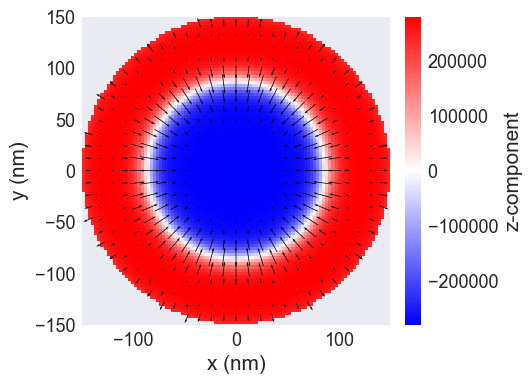

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
system.m.sel(z=12e-9).z.mpl.scalar(ax=ax, cmap="bwr", colorbar_label="z-component")
system.m.sel(z=12e-9).resample((25, 25)).mpl.vector(
    ax=ax, use_color=False, color="black"
)

In [10]:
Hmin = (0, 0, -4 / mm.consts.mu0)
Hmax = (0, 0, 4 / mm.consts.mu0)
n = 21

hd = oc.HysteresisDriver()
hd.drive(
    system,
    dirname=f"{RESULTS_PATH_HYSTERESIS}/saf_skyrmion-{D / 1e-9:.0f}nm-{Ms / 1e3:.0f}kA_m-hysteresis",
    Hsteps=[[(0, 0, 0), Hmax, 10], [Hmax, Hmin, 10], [Hmin, Hmax, 20]]
)

Running OOMMF (ExeOOMMFRunner)[2025/07/09 13:10]... (265.5 s)


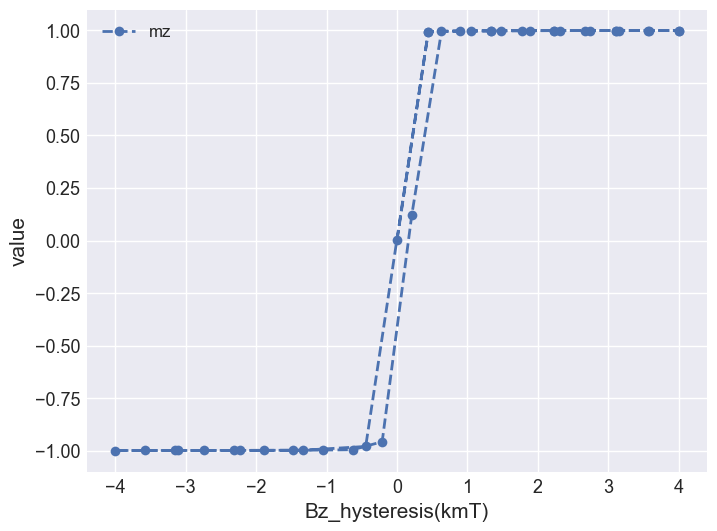

In [11]:
system.table.mpl(
    x="Bz_hysteresis", y=["mz"], marker="o", linewidth=2, linestyle="dashed"
)

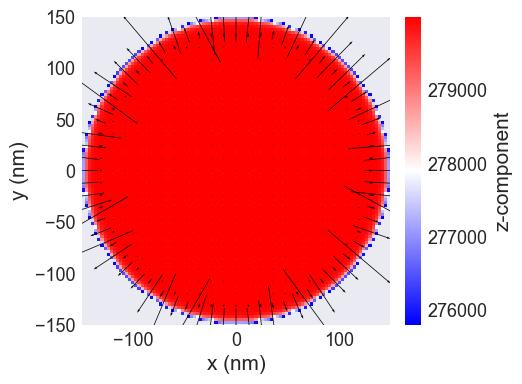

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
system.m.sel(z=12e-9).z.mpl.scalar(ax=ax, cmap="bwr", colorbar_label="z-component")
system.m.sel(z=12e-9).resample((25, 25)).mpl.vector(
    ax=ax, use_color=False, color="black"
)

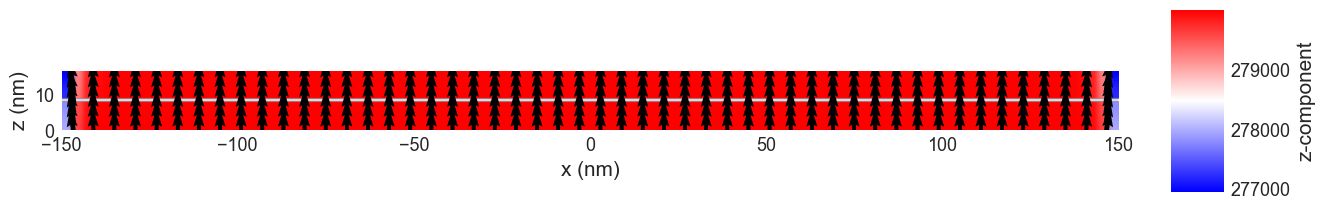

In [14]:
fig, ax = plt.subplots(figsize=(15, 5))
system.m.sel("y").z.mpl.scalar(ax=ax, cmap="bwr", colorbar_label="z-component")
system.m.sel("y").resample((50, 6)).mpl.vector(ax=ax, use_color=False, color="black")

In [9]:
import os 
import re
RESULTS_PATH_HYSTERESIS = "../results/saf_skyrmion-0.8nm-d_1-hysteresis"

def find_omf_file(driver_path):
  dir_list = os.listdir(driver_path)
  r = re.compile("saf.*omf")
  omf_file_path = list(filter(r.match, dir_list))
  #print(f"Founde .omf file as {omf_file_path}")
  return omf_file_path


In [10]:
omf_files = find_omf_file(f'{RESULTS_PATH_HYSTERESIS}/saf_skyrmion-300nm-280kA_m-hysteresis/saf_skyrmion_hysteresis/drive-1')

In [15]:
D = 300 # nm
Ms = 280 # kA_m
images_path = '../images/hysteresis/saf_skyrmion-300nm-280kA_m-hysteresis'
for i, omf_file in enumerate(omf_files):
    field_path_file = f'{RESULTS_PATH_HYSTERESIS}/saf_skyrmion-300nm-280kA_m-hysteresis/saf_skyrmion_hysteresis/drive-1/{omf_file}'
    read_field = df.Field.from_file(field_path_file)

    fig, axs = plt.subplots(
        figsize=(12, 6),
        nrows=1,
        ncols=2
    )
    read_field.sel(z=5e-9).z.mpl.scalar(ax=axs[0],cmap='coolwarm')
    read_field.sel(z=5e-9).resample((25, 25)).mpl.vector(
        ax=axs[0], use_color=False, color="black"
    )
    read_field.sel(z=12e-9).z.mpl.scalar(ax=axs[1],cmap='coolwarm')
    read_field.sel(z=12e-9).resample((25, 25)).mpl.vector(
        ax=axs[1], use_color=False, color="black"
    )
    
    axs[0].set_title(r"Bottom Layer: $z = 5 \times 10^{-9}$ m")
    axs[1].set_title(r"Top Layer: $z = 12 \times 10^{-9}$ m")
    
    fig.suptitle(
        rf"State at step={i+1}",
        fontsize='xx-large'
    )
    fig.tight_layout()
    fig.savefig(f"{images_path}/skyrmion-{D}nm-{Ms}kA_m-step_{i+1}.png")
    plt.close(fig)